In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('C:/Users/Fedor/Downloads/ab_data.csv')
df.head()

,user_id,group,converted,revenue,time_sec,clicks,sessions,device
0,A_000,A,0,0.00,42.6,4,2,mobile
1,A_001,A,1,133.77,71.1,2,2,mobile
2,A_002,A,0,0.00,73.3,6,1,mobile
3,A_003,A,0,0.00,47.6,3,1,mobile
4,A_004,A,0,0.00,48.9,0,5,desktop


In [22]:
#  SRM (Sample Ratio Mismatch) → проверка соответствия фактического соотношения групп ожидаемому (критерий χ²)
# Являются ли группы для A/B теста одинаковыми по размеру
from scipy.stats import chisquare

observed = df['group'].value_counts().sort_index()
print(f'observed: {observed}')


expected = [df.shape[0] / 2, df.shape[0] / 2]  
chi2, p = chisquare(f_obs=observed.values, f_exp=expected)

print(f"chi2 = {chi2:.4f}, p = {p:.4f}")

observed: group
A    60
B    60
Name: count, dtype: int64
chi2 = 0.0000, p = 1.0000


In [6]:
df['converted'].describe()

count    120.000000
mean       0.166667
std        0.374241
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: converted, dtype: float64

In [12]:
df['converted'].value_counts()

converted
0    100
1     20
Name: count, dtype: int64

In [15]:
# Поиск полных дублей и дублей id
df['user_id'].duplicated().sum(), df.duplicated().sum()   

(np.int64(0), np.int64(0))

In [46]:
# СТроим таблицу 2x2 (это EDA для бинарной метрики), а также проверка для применимости критериев (Фишер, Z-тест,Хи-квадрат)

table_2x2 = pd.crosstab(df['group'],df['converted'],  
                        # margins=True, 
                        # margins_name='Total'
                        )
table_2x2

converted,0,1
group,,
A,52,8
B,48,12


In [47]:
# Expected — то, что было бы в ячейках, если бы группа и конверсия были независимы (H₀), при тех же маргиналах.
# Смысл: если бы группа не влияла на конверсию, то в каждой группе доля конвертировавших была бы одинаковой
# А увидели 8 и 12 в таблице выше

row_sums = table_2x2.sum(axis=1)    # Series: A=60, B=60
col_sums = table_2x2.sum(axis=0)    # Series: 0=100, 1=20
n = table_2x2.values.sum()          # 120

expected_manual = pd.DataFrame(
    [[row_sums[i] * col_sums[j] / n for j in table_2x2.columns] for i in table_2x2.index],
    index=table_2x2.index, columns=table_2x2.columns
)
print(expected_manual)

converted     0     1
group                
A          50.0  10.0
B          50.0  10.0


In [48]:
# Смотрим минимальное значения ячеек после "выравнивания" конверсий у групп
# Если хотя бы одно значение в ячейке меньше 5, то испольщуется тест Фишера
# Если все значения ячеек >=5, то будет использоваться либо Z-тест, либо Хи-квадрат

min_expected = expected_manual.values.min()
print(f"min(Expected) = {min_expected:.2f}")
print("Условие >= 5:", min_expected >= 5) 

min(Expected) = 10.00
Условие >= 5: True


In [59]:
# Берем z-тест, потому что четко указывает какая группа лучше (Хи-квадрат говорит в целом о том, что разница есть)
# У нас очень маленькая выборка, поэтому будем увеличивать мощность

from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

count = table_2x2[1].values         # [8, 12]
nobs  = table_2x2.sum(axis=1).values  # [60, 60]

z, p = proportions_ztest(count, nobs, alternative='two-sided')

ci_low, ci_high = confint_proportions_2indep(
    count1=count[1], nobs1=nobs[1],
    count2=count[0], nobs2=nobs[0],
    method='wald'    # или 'newcomb' — устойчивее при малых n
)

p_A = count[0]/nobs[0]
print(f'Конверсия А: {p_A*100:.1f}%')
p_B = count[1]/nobs[1]
print(f'Конверсия B: {p_B*100:.1f}%')

print(f"Z = {z:.3f}, p = {p:.4f}")
print(f"Доверительный интервал (B−A) 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Прирост конверсии B по отношению к А: {(count[1]/nobs[1] - count[0]/nobs[0]) / (count[0]/nobs[0]) * 100:.1f}%")

Конверсия А: 13.3%
Конверсия B: 20.0%
Z = -0.980, p = 0.3272
Доверительный интервал (B−A) 95% CI: [-0.0662, 0.1995]
Прирост конверсии B по отношению к А: 50.0%




### 1. Что такое мощность

**Мощность (1 – β)** — это вероятность обнаружить эффект, если он реально существует.

* **β (бета)** — вероятность пропустить реальный эффект (ошибка II рода).
* **1 – β** — вероятность его поймать.

Стандарт в индустрии: **мощность ≥ 0.80**. То есть если эффект есть, мы должны его увидеть в 80% случаев.

---

### 2. Четыре исхода любого теста

Чтобы понять мощность, нужно увидеть всю картину. Мы проверяем гипотезу H₀ («эффекта нет»), а реальность может быть любой:

| | H₀ верна (эффекта нет) | H₀ ложна (эффект есть) |
| :--- | :--- | :--- |
| **Отвергли H₀ (p < 0.05)** | ❌ Ошибка I рода (α) | ✅ Правильно поймали (мощность 1–β) |
| **Не отвергли H₀ (p ≥ 0.05)** | ✅ Правильно не отвергли | ❌ Ошибка II рода (β) |

* **α = 0.05** — «заранее согласились ошибаться в 5% случаев, когда эффекта нет».
* **β** — «сколько раз мы упустим эффект, когда он есть». **Мощность = 1 – β**.

Если **мощность = 0.80**, то в 20% случаев с реальным эффектом мы его не увидим. Это нормально — зато в 80% увидим.

---

### 3. Что определяет мощность

Мощность зависит от четырёх вещей, и все они между собой связаны:

| Параметр | Что это | Как влияет на мощность |
| :--- | :--- | :--- |
| **n** | размер выборки в группе | ↑ n → ↑ мощность |
| **α** | уровень значимости | ↑ α → ↑ мощность (но ↑ ложноположительных) |
| **MDE / effect size** | истинный размер эффекта | ↑ эффект → ↑ мощность |
| **σ** (или ρ) | разброс в данных | ↑ разброс → ↓ мощность |

In [71]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize


# Cohen's h — это стандартизированный размер эффекта для пропорций. 
# Он переводит разницу между двумя пропорциями в безразмерную величину — такую, которая не зависит от базовой конверсии.
effect = proportion_effectsize(p_B, p_A)   # Cohen's h
print(f"Cohen's h = {effect:.4f}")

analysis = NormalIndPower()

power = analysis.power(
    effect_size=effect,
    nobs1=60,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)
print(f"Достигнутая мощность = {power:.3f}")

# Достигнутая мощность = 0.166
# Это вероятность поймать наш истинный эффект (h = 0.18) при n = 60 на группу и α = 0.05.

# У нас h = 0.18 — чуть ниже границы «маленького» (0.2	маленький, 0.5	средний, 0.8	большой)
# То есть эффект +6.7 п.п. на базе 13,3% — слабый с точки зрения статистики

Cohen's h = 0.1797
Достигнутая мощность = 0.166


In [72]:
# Чтобы поймать h = 0.18 с мощностью 0.80 нужно 486 наблюдений в группе

n_needed = analysis.solve_power(
    effect_size=effect,
    power=0.80,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)
print(f"Нужно n на группу: {n_needed:.0f}")

Нужно n на группу: 486


In [73]:
# Минимальный h, который мы можем поймать при данных n и power

mde = analysis.solve_power(
    effect_size=None,
    nobs1=60,
    power=0.80,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)
print(f"MDE (Cohen's h) = {mde:.4f}")

MDE (Cohen's h) = 0.5115


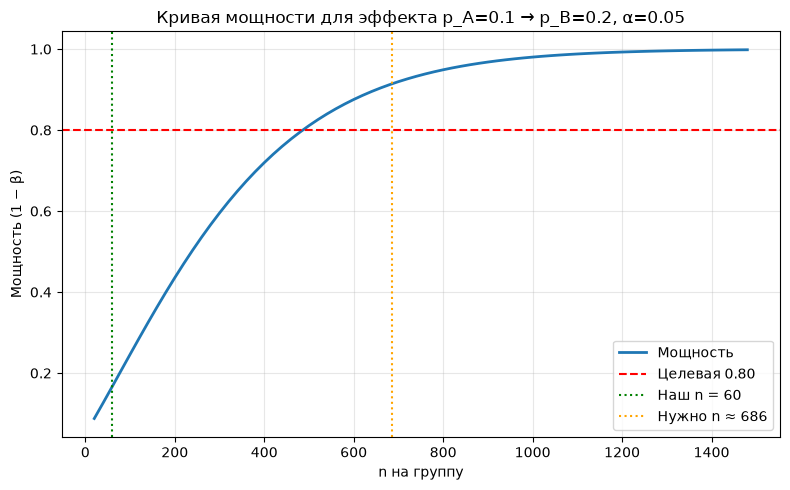

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect = proportion_effectsize(p_B, p_A)
analysis = NormalIndPower()

ns = np.arange(20, 1500, 20)
powers = [analysis.power(effect_size=effect, nobs1=n,
                         alpha=0.05, ratio=1,
                         alternative='two-sided') for n in ns]

plt.figure(figsize=(8, 5))
plt.plot(ns, powers, linewidth=2, label='Мощность')
plt.axhline(0.80, color='red', linestyle='--', label='Целевая 0.80')
plt.axvline(60, color='green', linestyle=':', label='Наш n = 60')
plt.axvline(686, color='orange', linestyle=':', label='Нужно n ≈ 686')
plt.xlabel('n на группу')
plt.ylabel('Мощность (1 − β)')
plt.title(f'Кривая мощности для эффекта p_A={p_A:.1f} → p_B={p_B:.1f}, α=0.05')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()